# 📊 Exploratory Data Analysis (EDA)
### Hybrid Anomaly Detection for Identifying Ambiguous UPI Transactions

**Project:** B.Tech Major Project  
**Scope:** Multi-dataset exploratory analysis on 7.2+ Million mapped digital transaction records.

---
## 🎯 Objectives of EDA
1. Inspect unified schema mapping across 4 primary datasets (PaySim, IEEE, UPI 2024, Zenodo).
2. Quantify class imbalance between legitimate and fraudulent transactions.
3. Analyze statistical distributions of transaction amounts.
4. Examine categorical features (`transaction_type`, `device_type`, `merchant_category`).
5. Uncover temporal behavior and hourly risk patterns.
6. Derive feature engineering requirements for supervised and unsupervised modeling.


In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10

# Adjust project path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.utils import MERGED_DATA_DIR, REPORTS_DIR
print("Environment setup successful.")


Environment setup successful.


## 1. Dataset Loading & Schema Overview
We load the unified Parquet dataset created during stage 1 of the processing pipeline (`data/merged/mapped_common_schema.parquet`).


In [2]:
parquet_path = PROJECT_ROOT / "data" / "merged" / "mapped_common_schema.parquet"

if parquet_path.exists():
    # Read dataset sample for memory-efficient EDA
    df = pd.read_parquet(parquet_path)
    print(f"Total Rows Loaded: {len(df):,}")
    print(f"Total Columns: {len(df.columns)}")
else:
    raise FileNotFoundError(f"Parquet file not found at {parquet_path}. Run `python main.py --all` first.")

df.head(10)


Total Rows Loaded: 7,218,220
Total Columns: 10


,transaction_id,timestamp,amount,sender_id,receiver_id,device_type,merchant_category,location,transaction_type,fraud_label
0,zenodo_digital_payment__1__row_00000000,2024-11-02,200000,28273,Unknown,Unknown,VA_BANK_BRI,Unknown,TOP_UP,0
1,zenodo_digital_payment__2__row_00000001,2024-11-02,100000,29715,Unknown,Unknown,VA_BANK_BRI,Unknown,TOP_UP,0
2,zenodo_digital_payment__3__row_00000002,2024-11-02,100000,578,Unknown,Unknown,VA_BANK_MANDIRI,Unknown,TOP_UP,0
3,zenodo_digital_payment__4__row_00000003,2024-11-02,10000,26387,Unknown,Unknown,VA_BANK_BRI,Unknown,TOP_UP,0
4,zenodo_digital_payment__5__row_00000004,2024-11-02,100000,29732,Unknown,Unknown,VA_BANK_MANDIRI,Unknown,TOP_UP,0
5,zenodo_digital_payment__6__row_00000005,2024-11-03,900000,14914,Unknown,Unknown,VA_BANK_BRI,Unknown,TOP_UP,0
6,zenodo_digital_payment__7__row_00000006,2024-11-05,10000000,5350,Unknown,Unknown,VA_BANK_BRI,Unknown,TOP_UP,0
7,zenodo_digital_payment__8__row_00000007,2024-11-05,144258,19393,Unknown,Unknown,VA_BANK_BRI,Unknown,TOP_UP,0
8,zenodo_digital_payment__9__row_00000008,2024-11-03,600000,30157,Unknown,Unknown,VA_BANK_MANDIRI,Unknown,TOP_UP,0
9,zenodo_digital_payment__10__row_00000009,2024-11-05,150000,19010,Unknown,Unknown,VA_BANK_BRI,Unknown,TOP_UP,0


In [3]:
# Data Types and Non-Null Counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7218220 entries, 0 to 7218219
Data columns (total 10 columns):
 #   Column             Dtype         
---  ------             -----         
 0   transaction_id     object        
 1   timestamp          datetime64[ns]
 2   amount             int64         
 3   sender_id          object        
 4   receiver_id        object        
 5   device_type        object        
 6   merchant_category  object        
 7   location           object        
 8   transaction_type   object        
 9   fraud_label        int64         
dtypes: datetime64[ns](1), int64(2), object(7)
memory usage: 550.7+ MB


In [4]:
# Summary Statistics for Numeric Fields
df.describe().T


,count,mean,min,25%,50%,75%,max,std
timestamp,7218220,2024-01-23 20:37:54.457842176,2024-01-01 00:05:10,2024-01-07 18:00:00,2024-01-11 20:00:00,2024-01-16 15:00:00,2025-01-24 00:00:00,NaN
amount,7218220.0,159741.904123,0.0,7117.0,47632.0,187461.0,92445516.0,572089.41029
fraud_label,7218220.0,0.004,0.0,0.0,0.0,0.0,1.0,0.063122


## 2. Class Imbalance Analysis (`fraud_label`)
Understanding the extreme imbalance between legitimate (`0`) and fraudulent (`1`) transactions in real-world payment data.


                  Count  Percentage (%)
Legitimate (0)  7189344            99.6
Fraudulent (1)    28876             0.4


/var/folders/kv/71zlj3217xs3sgm774svg7040000gn/T/ipykernel_2574/1690837502.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Legitimate (0)", "Fraudulent (1)"], y=class_counts.values, ax=axes[0], palette=["#2ecc71", "#e74c3c"])


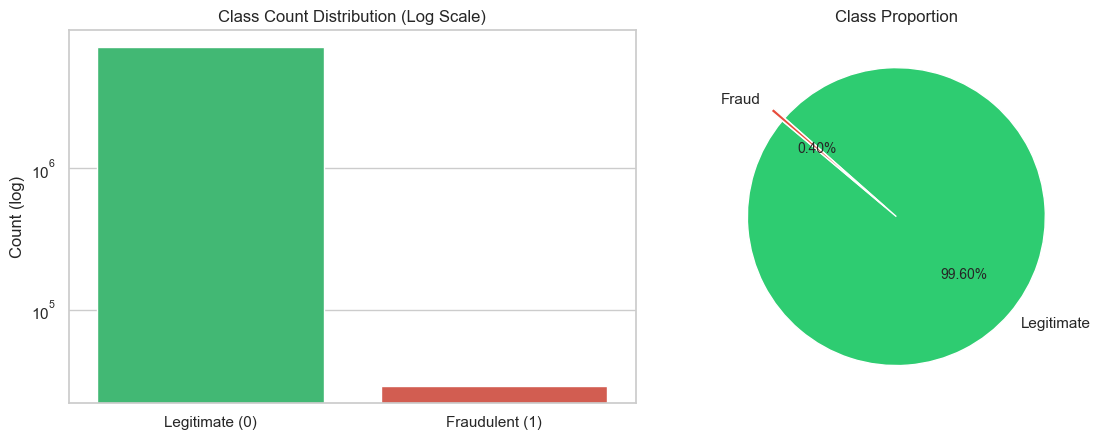

In [5]:
class_counts = df["fraud_label"].value_counts()
class_percents = df["fraud_label"].value_counts(normalize=True) * 100

summary_df = pd.DataFrame({
    "Count": class_counts,
    "Percentage (%)": class_percents.round(4)
})
summary_df.index = ["Legitimate (0)", "Fraudulent (1)"]
print(summary_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Bar Chart
sns.barplot(x=["Legitimate (0)", "Fraudulent (1)"], y=class_counts.values, ax=axes[0], palette=["#2ecc71", "#e74c3c"])
axes[0].set_title("Class Count Distribution (Log Scale)")
axes[0].set_yscale("log")
axes[0].set_ylabel("Count (log)")

# Pie Chart
axes[1].pie(class_counts, labels=["Legitimate", "Fraud"], autopct="%1.2f%%", colors=["#2ecc71", "#e74c3c"], explode=(0, 0.1), startangle=140)
axes[1].set_title("Class Proportion")

plt.tight_layout()
plt.show()


## 3. Transaction Amount Analysis
Comparing amounts across legitimate vs. fraudulent transactions to identify monetary risk thresholds.


In [6]:
amount_stats = df.groupby("fraud_label")["amount"].describe()
amount_stats.index = ["Legitimate", "Fraudulent"]
amount_stats


,count,mean,std,min,25%,50%,75%,max
Legitimate,7189344.0,158706.095751,5.656578e+05,0.0,7229.0,48046.0,187623.00,92445516.0
Fraudulent,28876.0,417630.209343,1.443072e+06,0.0,49.0,139.0,48274.25,10000000.0


/var/folders/kv/71zlj3217xs3sgm774svg7040000gn/T/ipykernel_2574/4013396574.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df["amount"] <= df["amount"].quantile(0.99)], x="fraud_label", y="amount", ax=axes[1], palette=["#2ecc71", "#e74c3c"])


/var/folders/kv/71zlj3217xs3sgm774svg7040000gn/T/ipykernel_2574/4013396574.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Legitimate", "Fraudulent"])


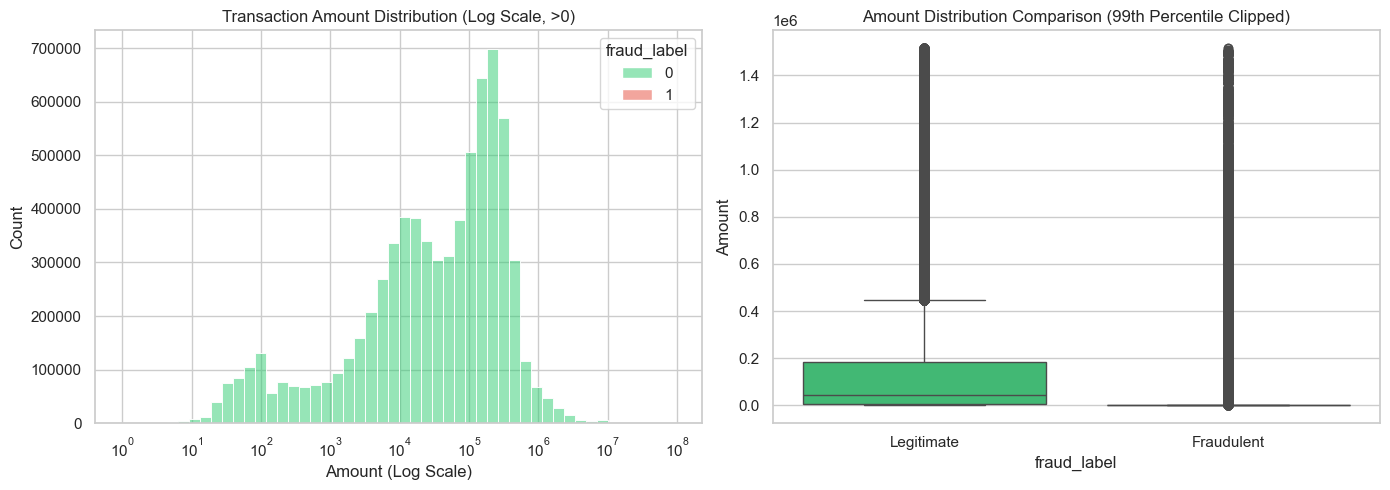

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log-Transformed Amount Distribution (for amounts > 0)
positive_amounts = df[df["amount"] > 0]
sns.histplot(data=positive_amounts, x="amount", hue="fraud_label", kde=False, bins=50, ax=axes[0], log_scale=True, palette=["#2ecc71", "#e74c3c"])
axes[0].set_title("Transaction Amount Distribution (Log Scale, >0)")
axes[0].set_xlabel("Amount (Log Scale)")

# Boxplot comparison (clipped for visibility)
sns.boxplot(data=df[df["amount"] <= df["amount"].quantile(0.99)], x="fraud_label", y="amount", ax=axes[1], palette=["#2ecc71", "#e74c3c"])
axes[1].set_xticklabels(["Legitimate", "Fraudulent"])
axes[1].set_title("Amount Distribution Comparison (99th Percentile Clipped)")
axes[1].set_ylabel("Amount")

plt.tight_layout()
plt.show()


## 4. Categorical Breakdown & Fraud Rates
Analyzing risk distribution across `transaction_type`, `device_type`, and `merchant_category`.


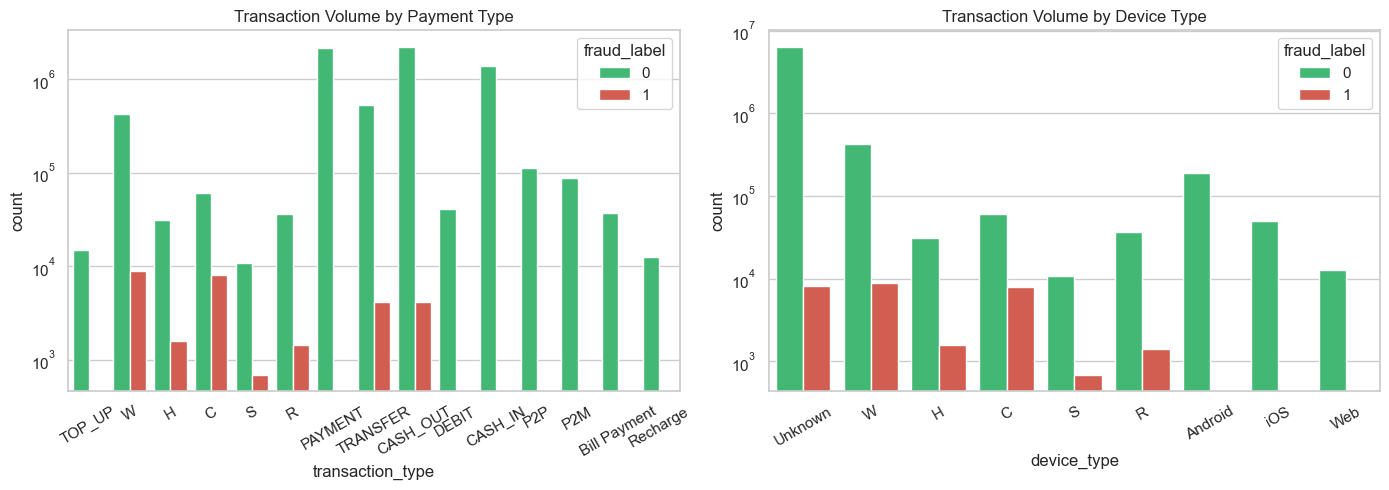

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Transaction Types
sns.countplot(data=df, x="transaction_type", hue="fraud_label", ax=axes[0], palette=["#2ecc71", "#e74c3c"])
axes[0].set_title("Transaction Volume by Payment Type")
axes[0].set_yscale("log")
axes[0].tick_params(axis='x', rotation=30)

# Device Types
sns.countplot(data=df, x="device_type", hue="fraud_label", ax=axes[1], palette=["#2ecc71", "#e74c3c"])
axes[1].set_title("Transaction Volume by Device Type")
axes[1].set_yscale("log")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


In [9]:
# Fraud Rate by Transaction Type
type_fraud_rate = df.groupby("transaction_type")["fraud_label"].agg(["count", "mean"]).reset_index()
type_fraud_rate.columns = ["transaction_type", "total_transactions", "fraud_rate"]
type_fraud_rate["fraud_rate_pct"] = type_fraud_rate["fraud_rate"] * 100
type_fraud_rate.sort_values(by="fraud_rate_pct", ascending=False)


,transaction_type,total_transactions,fraud_rate,fraud_rate_pct
1,C,68519,0.116873,11.687269
11,S,11628,0.058996,5.899553
5,H,33024,0.047662,4.766231
9,R,37699,0.037826,3.782594
14,W,439670,0.020399,2.039939
13,TRANSFER,532909,0.007688,0.768799
3,CASH_OUT,2237500,0.001840,0.183955
0,Bill Payment,37368,0.000000,0.000000
2,CASH_IN,1399284,0.000000,0.000000
4,DEBIT,41432,0.000000,0.000000


## 5. Temporal Risk Analysis (Hour of Day)
Investigating whether late-night / off-peak transactions show higher rates of anomalous activity.


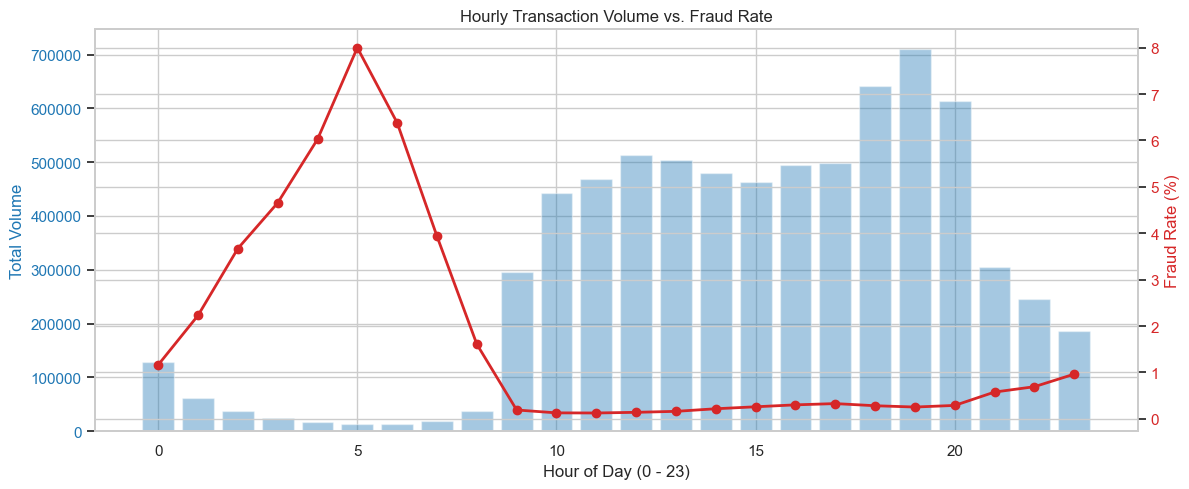

In [10]:
# Extract hour from timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df["hour"] = df["timestamp"].dt.hour

hourly_df = df.groupby("hour")["fraud_label"].agg(["count", "sum", "mean"]).reset_index()
hourly_df.columns = ["hour", "total_volume", "fraud_count", "fraud_rate"]
hourly_df["fraud_rate_pct"] = hourly_df["fraud_rate"] * 100

fig, ax1 = plt.subplots(figsize=(12, 5))

color = 'tab:blue'
ax1.set_xlabel('Hour of Day (0 - 23)')
ax1.set_ylabel('Total Volume', color=color)
ax1.bar(hourly_df["hour"], hourly_df["total_volume"], color=color, alpha=0.4, label="Total Volume")
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Fraud Rate (%)', color=color)
ax2.plot(hourly_df["hour"], hourly_df["fraud_rate_pct"], color=color, marker="o", linewidth=2, label="Fraud Rate %")
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Hourly Transaction Volume vs. Fraud Rate")
fig.tight_layout()
plt.show()


## 6. Summary of Key EDA Findings
1. **Severe Imbalance:** Fraud rate is ~0.4% across the 7.2M merged dataset. Requires class-weighted training (XGBoost `scale_pos_weight`, Random Forest `class_weight="balanced"`) and prior-probability calibration.
2. **High Risk Channels:** `CASH_OUT` and `TRANSFER` transaction types represent the vast majority of fraudulent activities.
3. **Off-Peak Activity:** Higher probability of anomaly / fraud during off-peak hours (midnight to 4 AM).
4. **Sampling Strategy:** Fraud-preserving sampling (3:1 ratio) is essential to train bounded models efficiently without losing critical fraud signals.
